# CallHub – Phone Directory Management System
## CS 432 Databases | Module A: Lightweight DBMS with B+ Tree Index

---
## 1. Introduction

### Problem Statement
In big institutes like IIT Gandhinagar, contact details of students, teachers, and staff are often kept in many different places like Excel sheets or paper records. Because of this, finding someone’s contact information can be slow and confusing.

CallHub solves this problem by keeping all contact details in one place. It allows users to quickly search and find information. It is also secure and gives access based on roles, so only the right people can see certain information.

### Proposed Solution – B+ Tree DBMS
This module implements a lightweight **in-memory DBMS** that mirrors the CallHub MySQL schema (Assignment 1), using a **B+ Tree** as the indexing engine. The B+ Tree provides:
- **O(log n)** insertion, deletion, exact-match search
- **Efficient range queries** via leaf-level linked list
- **Schema-aware Table** with type validation
- **Two-level DatabaseManager**: `{db_name → {table_name → Table}}`

**Video Demonstration:** (https://drive.google.com/file/d/1S_bG8CRIV-bTOH0ljurJJxwCryHjpW9u/view?usp=sharing)

---

## 2. Setup

In [39]:
import sys, os, time, random, tracemalloc, statistics, string, warnings
import matplotlib.pyplot as plt
from IPython.display import SVG, display

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

from database.db_manager import DatabaseManager
from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB

C_BLUE, C_RED, C_GREEN, BG = '#1a73e8', '#e84343', '#34a853', '#f8f9fa'
print('Imports OK')

Imports OK


---
## 3. SubTask 1 – B+ Tree Implementation
### 3.1 Create the CallHub database and tables

In [40]:
db_manager = DatabaseManager()

print(db_manager.create_database('CallHub'))
print('Databases:', db_manager.list_databases())

(True, "Database 'CallHub' created successfully")
Databases: ['CallHub']


In [41]:

member_schema = {
    'member_id':     int,
    'member_name':   str,
    'iit_email':     str,
    'primary_phone': str,
    'dob':           str,
    'department_id': int,
    'is_at_campus':  bool,
    'join_date':     str
}

department_schema = {
    'department_id':   int,
    'department_name': str,
    'building':        str,
    'opening_hours':   str,
    'closing_hours':   str
}

role_schema = {
    'role_id':   int,
    'role_name': str
}

lab_schema = {
    'lab_id':     int,
    'lab_name':   str,
    'department_id': int,
    'building':   str,
    'room_no':    str,
    'contact_no': str
}

print(db_manager.create_table('CallHub', 'Member',     member_schema,     order=6, search_key='member_id'))
print(db_manager.create_table('CallHub', 'Department', department_schema, order=6, search_key='department_id'))
print(db_manager.create_table('CallHub', 'Role',       role_schema,       order=6, search_key='role_id'))
print(db_manager.create_table('CallHub', 'Lab',        lab_schema,        order=6, search_key='lab_id'))

tables, _ = db_manager.list_tables('CallHub')
print('\nTables in CallHub:', tables)

(True, "Table 'Member' created successfully in database 'CallHub'")
(True, "Table 'Department' created successfully in database 'CallHub'")
(True, "Table 'Role' created successfully in database 'CallHub'")
(True, "Table 'Lab' created successfully in database 'CallHub'")

Tables in CallHub: ['Member', 'Department', 'Role', 'Lab']


In [42]:

member_table, _     = db_manager.get_table('CallHub', 'Member')
department_table, _ = db_manager.get_table('CallHub', 'Department')
role_table, _       = db_manager.get_table('CallHub', 'Role')
lab_table, _        = db_manager.get_table('CallHub', 'Lab')

print(member_table)
print('Empty table get_all():', member_table.get_all())

Table(name='Member', search_key='member_id', records=0, order=6)
Empty table get_all(): []


### 3.2 Load sample data (from Assignment 1 sample_data.sql)

In [43]:

departments = [
    {'department_id':1,  'department_name':'Computer Science',       'building':'Block A','opening_hours':'09:00','closing_hours':'17:00'},
    {'department_id':2,  'department_name':'Information Technology', 'building':'Block A','opening_hours':'09:00','closing_hours':'17:00'},
    {'department_id':3,  'department_name':'Electrical Engineering', 'building':'Block B','opening_hours':'09:00','closing_hours':'17:00'},
    {'department_id':4,  'department_name':'Mechanical Engineering', 'building':'Block C','opening_hours':'09:00','closing_hours':'17:00'},
    {'department_id':5,  'department_name':'Civil Engineering',      'building':'Block D','opening_hours':'09:00','closing_hours':'17:00'},
    {'department_id':6,  'department_name':'Electronics',            'building':'Block E','opening_hours':'09:00','closing_hours':'17:00'},
    {'department_id':7,  'department_name':'Data Science',           'building':'Block F','opening_hours':'09:00','closing_hours':'17:00'},
    {'department_id':8,  'department_name':'AI',                     'building':'Block F','opening_hours':'09:00','closing_hours':'17:00'},
    {'department_id':9,  'department_name':'Cyber Security',         'building':'Block G','opening_hours':'09:00','closing_hours':'17:00'},
    {'department_id':10, 'department_name':'Administration',         'building':'Admin',  'opening_hours':'09:00','closing_hours':'17:00'},
]
for d in departments:
    department_table.insert(d)

# Load Role data
roles = [
    {'role_id':1,'role_name':'Student'},      {'role_id':2,'role_name':'Professor'},
    {'role_id':3,'role_name':'Assistant Professor'}, {'role_id':4,'role_name':'Associate Professor'},
    {'role_id':5,'role_name':'Lab Assistant'},{'role_id':6,'role_name':'Technician'},
    {'role_id':7,'role_name':'HOD'},          {'role_id':8,'role_name':'Dean'},
    {'role_id':9,'role_name':'Director'},     {'role_id':10,'role_name':'Admin Staff'},
]
for r in roles:
    role_table.insert(r)

# Load Lab data
labs = [
    {'lab_id':1,'lab_name':'AI Lab',          'department_id':8,'building':'Block F','room_no':'F201','contact_no':'7100000001'},
    {'lab_id':2,'lab_name':'Robotics Lab',    'department_id':4,'building':'Block C','room_no':'C301','contact_no':'7100000002'},
    {'lab_id':3,'lab_name':'Power Systems Lab','department_id':3,'building':'Block B','room_no':'B210','contact_no':'7100000003'},
    {'lab_id':4,'lab_name':'Civil Survey Lab','department_id':5,'building':'Block D','room_no':'D102','contact_no':'7100000004'},
    {'lab_id':5,'lab_name':'Electronics Lab', 'department_id':6,'building':'Block E','room_no':'E110','contact_no':'7100000005'},
]
for l in labs:
    lab_table.insert(l)

print(f'Departments: {department_table.count()} | Roles: {role_table.count()} | Labs: {lab_table.count()}')

Departments: 10 | Roles: 10 | Labs: 5


In [44]:
# Load all 20 Members from sample_data.sql
members = [
    {'member_id':1,  'member_name':'Amit Sharma',   'iit_email':'amit@org.in',   'primary_phone':'9000000001','dob':'2000-01-01','department_id':1,  'is_at_campus':True, 'join_date':'2022-07-01'},
    {'member_id':2,  'member_name':'Priya Verma',   'iit_email':'priya@org.in',  'primary_phone':'9000000002','dob':'1999-02-02','department_id':2,  'is_at_campus':True, 'join_date':'2021-07-01'},
    {'member_id':3,  'member_name':'Rahul Mehta',   'iit_email':'rahul@org.in',  'primary_phone':'9000000003','dob':'2001-03-03','department_id':3,  'is_at_campus':True, 'join_date':'2023-01-01'},
    {'member_id':4,  'member_name':'Sneha Iyer',    'iit_email':'sneha@org.in',  'primary_phone':'9000000004','dob':'1998-04-04','department_id':4,  'is_at_campus':True, 'join_date':'2020-07-01'},
    {'member_id':5,  'member_name':'Karan Patel',   'iit_email':'karan@org.in',  'primary_phone':'9000000005','dob':'1997-05-05','department_id':5,  'is_at_campus':True, 'join_date':'2019-07-01'},
    {'member_id':6,  'member_name':'Neha Gupta',    'iit_email':'neha@org.in',   'primary_phone':'9000000006','dob':'2000-06-06','department_id':6,  'is_at_campus':True, 'join_date':'2022-01-01'},
    {'member_id':7,  'member_name':'Arjun Nair',    'iit_email':'arjun@org.in',  'primary_phone':'9000000007','dob':'1996-07-07','department_id':7,  'is_at_campus':True, 'join_date':'2018-01-01'},
    {'member_id':8,  'member_name':'Pooja Singh',   'iit_email':'pooja@org.in',  'primary_phone':'9000000008','dob':'1995-08-08','department_id':8,  'is_at_campus':True, 'join_date':'2017-01-01'},
    {'member_id':9,  'member_name':'Rohit Das',     'iit_email':'rohit@org.in',  'primary_phone':'9000000009','dob':'1994-09-09','department_id':9,  'is_at_campus':True, 'join_date':'2016-01-01'},
    {'member_id':10, 'member_name':'Ananya Rao',    'iit_email':'ananya@org.in', 'primary_phone':'9000000010','dob':'2002-10-10','department_id':10, 'is_at_campus':True, 'join_date':'2023-07-01'},
    {'member_id':11, 'member_name':'Vikas Kumar',   'iit_email':'vikas@org.in',  'primary_phone':'9000000011','dob':'1993-01-11','department_id':1,  'is_at_campus':True, 'join_date':'2015-01-01'},
    {'member_id':12, 'member_name':'Meera Pillai',  'iit_email':'meera@org.in',  'primary_phone':'9000000012','dob':'1992-02-12','department_id':2,  'is_at_campus':True, 'join_date':'2014-01-01'},
    {'member_id':13, 'member_name':'Suresh Reddy',  'iit_email':'suresh@org.in', 'primary_phone':'9000000013','dob':'1991-03-13','department_id':3,  'is_at_campus':True, 'join_date':'2013-01-01'},
    {'member_id':14, 'member_name':'Kavita Joshi',  'iit_email':'kavita@org.in', 'primary_phone':'9000000014','dob':'1990-04-14','department_id':4,  'is_at_campus':True, 'join_date':'2012-01-01'},
    {'member_id':15, 'member_name':'Manoj Yadav',   'iit_email':'manoj@org.in',  'primary_phone':'9000000015','dob':'1989-05-15','department_id':5,  'is_at_campus':True, 'join_date':'2011-01-01'},
    {'member_id':16, 'member_name':'Deepak Jain',   'iit_email':'deepak@org.in', 'primary_phone':'9000000016','dob':'1988-06-16','department_id':6,  'is_at_campus':True, 'join_date':'2010-01-01'},
    {'member_id':17, 'member_name':'Farhan Ali',    'iit_email':'farhan@org.in', 'primary_phone':'9000000017','dob':'1987-07-17','department_id':7,  'is_at_campus':True, 'join_date':'2009-01-01'},
    {'member_id':18, 'member_name':'Ritu Saxena',   'iit_email':'ritu@org.in',   'primary_phone':'9000000018','dob':'1999-08-18','department_id':8,  'is_at_campus':True, 'join_date':'2021-01-01'},
    {'member_id':19, 'member_name':'Nikhil Bansal', 'iit_email':'nikhil@org.in', 'primary_phone':'9000000019','dob':'1998-09-19','department_id':9,  'is_at_campus':True, 'join_date':'2020-01-01'},
    {'member_id':20, 'member_name':'Tanya Kapoor',  'iit_email':'tanya@org.in',  'primary_phone':'9000000020','dob':'2001-10-20','department_id':10, 'is_at_campus':True, 'join_date':'2023-08-01'},
]

print('Inserting members...')
for m in members:
    result = member_table.insert(m)
    print(f'  insert({m["member_id"]}) → {result}')

print(f'\nTotal members: {member_table.count()}')
print(f'Tree height  : {member_table.tree_height()}')

Inserting members...
  insert(1) → (True, 1)
  insert(2) → (True, 2)
  insert(3) → (True, 3)
  insert(4) → (True, 4)
  insert(5) → (True, 5)
  insert(6) → (True, 6)
  insert(7) → (True, 7)
  insert(8) → (True, 8)
  insert(9) → (True, 9)
  insert(10) → (True, 10)
  insert(11) → (True, 11)
  insert(12) → (True, 12)
  insert(13) → (True, 13)
  insert(14) → (True, 14)
  insert(15) → (True, 15)
  insert(16) → (True, 16)
  insert(17) → (True, 17)
  insert(18) → (True, 18)
  insert(19) → (True, 19)
  insert(20) → (True, 20)

Total members: 20
Tree height  : 3


### 3.3 Exact Search

In [45]:
print('get(member_id=6):')
print(member_table.get(6))

print('\nget(member_id=14):')
print(member_table.get(14))

print('\nget(member_id=999) — not found:')
print(member_table.get(999))

get(member_id=6):
{'member_id': 6, 'member_name': 'Neha Gupta', 'iit_email': 'neha@org.in', 'primary_phone': '9000000006', 'dob': '2000-06-06', 'department_id': 6, 'is_at_campus': True, 'join_date': '2022-01-01'}

get(member_id=14):
{'member_id': 14, 'member_name': 'Kavita Joshi', 'iit_email': 'kavita@org.in', 'primary_phone': '9000000014', 'dob': '1990-04-14', 'department_id': 4, 'is_at_campus': True, 'join_date': '2012-01-01'}

get(member_id=999) — not found:
None


### 3.4 Update

In [46]:
print('Update member_id=3 (Rahul Mehta — change phone and department):')
print('Before:', member_table.get(3))

result = member_table.update(3, {'primary_phone': '9777777003', 'department_id': 1})
print('update() →', result)
print('After  :', member_table.get(3))

Update member_id=3 (Rahul Mehta — change phone and department):
Before: {'member_id': 3, 'member_name': 'Rahul Mehta', 'iit_email': 'rahul@org.in', 'primary_phone': '9000000003', 'dob': '2001-03-03', 'department_id': 3, 'is_at_campus': True, 'join_date': '2023-01-01'}
update() → (True, 'Record updated successfully')
After  : {'member_id': 3, 'member_name': 'Rahul Mehta', 'iit_email': 'rahul@org.in', 'primary_phone': '9777777003', 'dob': '2001-03-03', 'department_id': 1, 'is_at_campus': True, 'join_date': '2023-01-01'}


### 3.5 Range Query

In [47]:
print('range_query(5, 10):')
for mid, rec in member_table.range_query(5, 10):
    print(f'  [{mid}] {rec["member_name"]:16s} | dept_id={rec["department_id"]} | {rec["primary_phone"]}')

range_query(5, 10):
  [5] Karan Patel      | dept_id=5 | 9000000005
  [6] Neha Gupta       | dept_id=6 | 9000000006
  [7] Arjun Nair       | dept_id=7 | 9000000007
  [8] Pooja Singh      | dept_id=8 | 9000000008
  [9] Rohit Das        | dept_id=9 | 9000000009
  [10] Ananya Rao       | dept_id=10 | 9000000010


### 3.6 Deletion

In [48]:
print(f'Records before delete: {member_table.count()}')

print('delete(6)  →', member_table.delete(6))
print('delete(999)→', member_table.delete(999))  

print(f'Records after delete : {member_table.count()}')
print('get(6) after delete  :', member_table.get(6))

Records before delete: 20
delete(6)  → (True, 'Record deleted')
delete(999)→ (False, "Record with id '999' not found")
Records after delete : 19
get(6) after delete  : None


In [49]:
print('get_all() — all remaining members (sorted by member_id):')
for mid, rec in member_table.get_all():
    print(f'  [{mid:2d}] {rec["member_name"]:16s} | dept={rec["department_id"]} | {rec["iit_email"]}')

get_all() — all remaining members (sorted by member_id):
  [ 1] Amit Sharma      | dept=1 | amit@org.in
  [ 2] Priya Verma      | dept=2 | priya@org.in
  [ 3] Rahul Mehta      | dept=1 | rahul@org.in
  [ 4] Sneha Iyer       | dept=4 | sneha@org.in
  [ 5] Karan Patel      | dept=5 | karan@org.in
  [ 7] Arjun Nair       | dept=7 | arjun@org.in
  [ 8] Pooja Singh      | dept=8 | pooja@org.in
  [ 9] Rohit Das        | dept=9 | rohit@org.in
  [10] Ananya Rao       | dept=10 | ananya@org.in
  [11] Vikas Kumar      | dept=1 | vikas@org.in
  [12] Meera Pillai     | dept=2 | meera@org.in
  [13] Suresh Reddy     | dept=3 | suresh@org.in
  [14] Kavita Joshi     | dept=4 | kavita@org.in
  [15] Manoj Yadav      | dept=5 | manoj@org.in
  [16] Deepak Jain      | dept=6 | deepak@org.in
  [17] Farhan Ali       | dept=7 | farhan@org.in
  [18] Ritu Saxena      | dept=8 | ritu@org.in
  [19] Nikhil Bansal    | dept=9 | nikhil@org.in
  [20] Tanya Kapoor     | dept=10 | tanya@org.in


---
## 4. SubTask 3 – Visualisation with Graphviz

Tree structure (Member table, order=6):


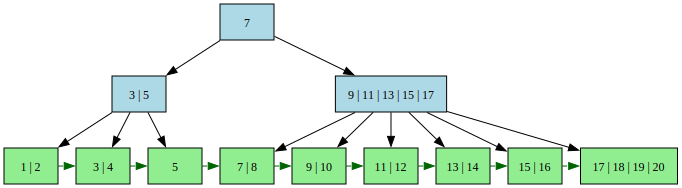

Height=3 | Records=19


In [50]:
print('Tree structure (Member table, order=6):')
dot = member_table.data.visualize_tree()
svg_data = dot.pipe(format='svg').decode('utf-8')
display(SVG(svg_data))
print(f'Height={member_table.tree_height()} | Records={member_table.count()}')

Incremental insertion — watch nodes split (order=4):
  After inserting  10 → height=1, keys=[10]
  After inserting  20 → height=1, keys=[10, 20]
  After inserting   5 → height=1, keys=[5, 10, 20]
  After inserting  15 → height=2, keys=[5, 10, 15, 20]
  After inserting  25 → height=2, keys=[5, 10, 15, 20, 25]
  After inserting  30 → height=2, keys=[5, 10, 15, 20, 25, 30]
  After inserting   3 → height=3, keys=[3, 5, 10, 15, 20, 25, 30]
  After inserting   8 → height=3, keys=[3, 5, 8, 10, 15, 20, 25, 30]
  After inserting  18 → height=3, keys=[3, 5, 8, 10, 15, 18, 20, 25, 30]
  After inserting  22 → height=3, keys=[3, 5, 8, 10, 15, 18, 20, 22, 25, 30]
  After inserting  28 → height=3, keys=[3, 5, 8, 10, 15, 18, 20, 22, 25, 28, 30]


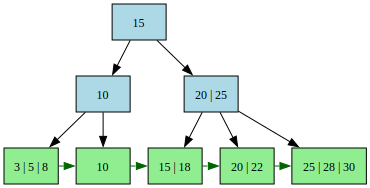

In [51]:
print('Incremental insertion — watch nodes split (order=4):')
demo = BPlusTree(order=4)
for k in [10, 20, 5, 15, 25, 30, 3, 8, 18, 22, 28]:
    demo.insert(k, {'key': k})
    print(f'  After inserting {k:3d} → height={demo.height()}, keys={[p[0] for p in demo.get_all()]}')

dot2 = demo.visualize_tree()
svg2 = dot2.pipe(format='svg').decode('utf-8')
display(SVG(svg2))

Department table B+ Tree:


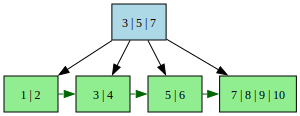

In [52]:
print('Department table B+ Tree:')
dot3 = department_table.data.visualize_tree()
svg3 = dot3.pipe(format='svg').decode('utf-8')
display(SVG(svg3))

---
## 5. SubTask 2 & 4 – Performance Analysis

In [53]:
def random_record_generator(schema, n):
    """Generate n random records matching a schema — same helper as in main.ipynb."""
    def random_value(dtype):
        if dtype == int:   return random.randint(1, 200_000)
        if dtype == float: return round(random.uniform(18.0, 60.0), 2)
        if dtype == str:   return ''.join(random.choices(string.ascii_letters, k=6))
        if dtype == bool:  return random.choice([True, False])
        return None
    records = []
    for _ in range(n):
        records.append({col: random_value(t) for col, t in schema.items()})
    return records


class PerformanceAnalyzer:
    """Benchmark B+ Tree vs BruteForceDB on CallHub Member-shaped records."""

    def __init__(self, sizes):
        self.sizes   = sizes
        self.results = {op: {'bpt': [], 'bf': []}
                        for op in ['insert','search','delete','range','random','memory']}

    def _make_keys(self, size):
        return random.sample(range(1, 500_000), size)

    def _rec(self, k):
        return {
            'member_id': k, 'member_name': f'Member_{k}',
            'iit_email': f'm{k}@org.in', 'primary_phone': f'9{k%10**9:09d}',
            'dob': '2000-01-01', 'department_id': k % 10 + 1,
            'is_at_campus': True, 'join_date': '2022-07-01'
        }

    def bench_insert(self, size):
        keys = self._make_keys(size)
        bpt = BPlusTree(order=6)
        t0  = time.perf_counter()
        for k in keys: bpt.insert(k, self._rec(k))
        bt  = time.perf_counter() - t0
        bf  = BruteForceDB()
        t0  = time.perf_counter()
        for k in keys: bf.insert(k, self._rec(k))
        bft = time.perf_counter() - t0
        return bt, bft, bpt, bf, keys

    def bench_search(self, bpt, bf, keys):
        sq  = random.sample(keys, min(len(keys), 300))
        t0  = time.perf_counter()
        for k in sq: bpt.search(k)
        bt  = time.perf_counter() - t0
        t0  = time.perf_counter()
        for k in sq: bf.search(k)
        return bt, time.perf_counter() - t0

    def bench_range(self, bpt, bf, keys):
        lo, hi = min(keys), max(keys)
        rl, rh = lo + (hi-lo)//4, lo + (hi-lo)//2
        RUNS   = 50
        t0 = time.perf_counter()
        for _ in range(RUNS): bpt.range_query(rl, rh)
        bt  = (time.perf_counter() - t0) / RUNS
        t0 = time.perf_counter()
        for _ in range(RUNS): bf.range_query(rl, rh)
        return bt, (time.perf_counter() - t0) / RUNS

    def bench_delete(self, bpt, bf, keys):
        dk  = random.sample(keys, min(len(keys), 150))
        t0  = time.perf_counter()
        for k in dk: bpt.delete(k)
        bt  = time.perf_counter() - t0
        t0  = time.perf_counter()
        for k in dk: bf.delete(k)
        return bt, time.perf_counter() - t0

    def bench_random(self, size):
        keys = list(range(1, size+1))
        bpt  = BPlusTree(order=6); bf = BruteForceDB()
        for k in keys[:size//2]: r=self._rec(k); bpt.insert(k,r); bf.insert(k,r)
        ops = random.choices(['insert','search','delete'], k=size)
        ks  = random.choices(keys, k=size)
        t0  = time.perf_counter()
        for op,k in zip(ops,ks):
            r=self._rec(k)
            if op=='insert': bpt.insert(k,r)
            elif op=='search': bpt.search(k)
            else: bpt.delete(k)
        bt  = time.perf_counter() - t0
        t0  = time.perf_counter()
        for op,k in zip(ops,ks):
            r=self._rec(k)
            if op=='insert': bf.insert(k,r)
            elif op=='search': bf.search(k)
            else: bf.delete(k)
        return bt, time.perf_counter() - t0

    def bench_memory(self, size):
        keys = self._make_keys(size)
        tracemalloc.start()
        bpt = BPlusTree(order=6)
        for k in keys: bpt.insert(k, self._rec(k))
        _, bpk = tracemalloc.get_traced_memory(); tracemalloc.stop()
        tracemalloc.start()
        bf = BruteForceDB()
        for k in keys: bf.insert(k, self._rec(k))
        _, bfk = tracemalloc.get_traced_memory(); tracemalloc.stop()
        return bpk/1024, bfk/1024

    def run(self):
        print(f'{"N":>7} {"Ins-BPT":>10} {"Ins-BF":>10} {"Srch-BPT":>10} {"Srch-BF":>10} {"Rng-BPT":>10} {"Rng-BF":>10} {"Del-BPT":>10} {"Del-BF":>10}')
        print('─'*97)
        for size in self.sizes:
            bi,bfi,bpt,bf,keys = self.bench_insert(size)
            bs,bfs = self.bench_search(bpt,bf,keys)
            br,bfr = self.bench_range(bpt,bf,keys)
            bd,bfd = self.bench_delete(bpt,bf,keys)
            bra,bfra = self.bench_random(size)
            bm,bfm   = self.bench_memory(size)
            for op,v in [('insert',(bi,bfi)),('search',(bs,bfs)),('range',(br,bfr)),
                         ('delete',(bd,bfd)),('random',(bra,bfra)),('memory',(bm,bfm))]:
                self.results[op]['bpt'].append(v[0])
                self.results[op]['bf'].append(v[1])
            print(f'{size:>7} {bi*1e3:>10.4f} {bfi*1e3:>10.4f} {bs*1e3:>10.4f} {bfs*1e3:>10.4f} {br*1e3:>10.4f} {bfr*1e3:>10.4f} {bd*1e3:>10.4f} {bfd*1e3:>10.4f}')
        print('\n Benchmarks complete.')
        return self.results


sizes    = list(range(100, 5100, 500))
analyzer = PerformanceAnalyzer(sizes)
results  = analyzer.run()

      N    Ins-BPT     Ins-BF   Srch-BPT    Srch-BF    Rng-BPT     Rng-BF    Del-BPT     Del-BF
─────────────────────────────────────────────────────────────────────────────────────────────────
    100     0.2620     0.7510     0.0891     0.1165     0.0052     0.0070     0.3126     0.3692
    600     3.2129    14.4749     0.3177     1.6474     0.0178     0.0253     0.3071     1.0901
   1100    16.3153    34.5958     0.3423     2.9561     0.0243     0.0408     0.3162     1.7735
   1600     3.5643    37.8084     0.3270     4.1195     0.0368     0.0616     0.3140     3.1692
   2100     4.6343    60.4529     0.2900     4.8387     0.0472     0.0809     0.3028     4.0180
   2600     5.9515    92.3485     0.3090     6.4712     0.0577     0.1004     0.3168     5.1692
   3100     7.3126   129.7930     0.3175     7.4156     0.0701     0.1202     0.3299     6.2343
   3600     8.5633   174.0199     0.3243     8.8693     0.0778     0.1385     0.3345     6.9007
   4100     9.7003   229.1895     0.33

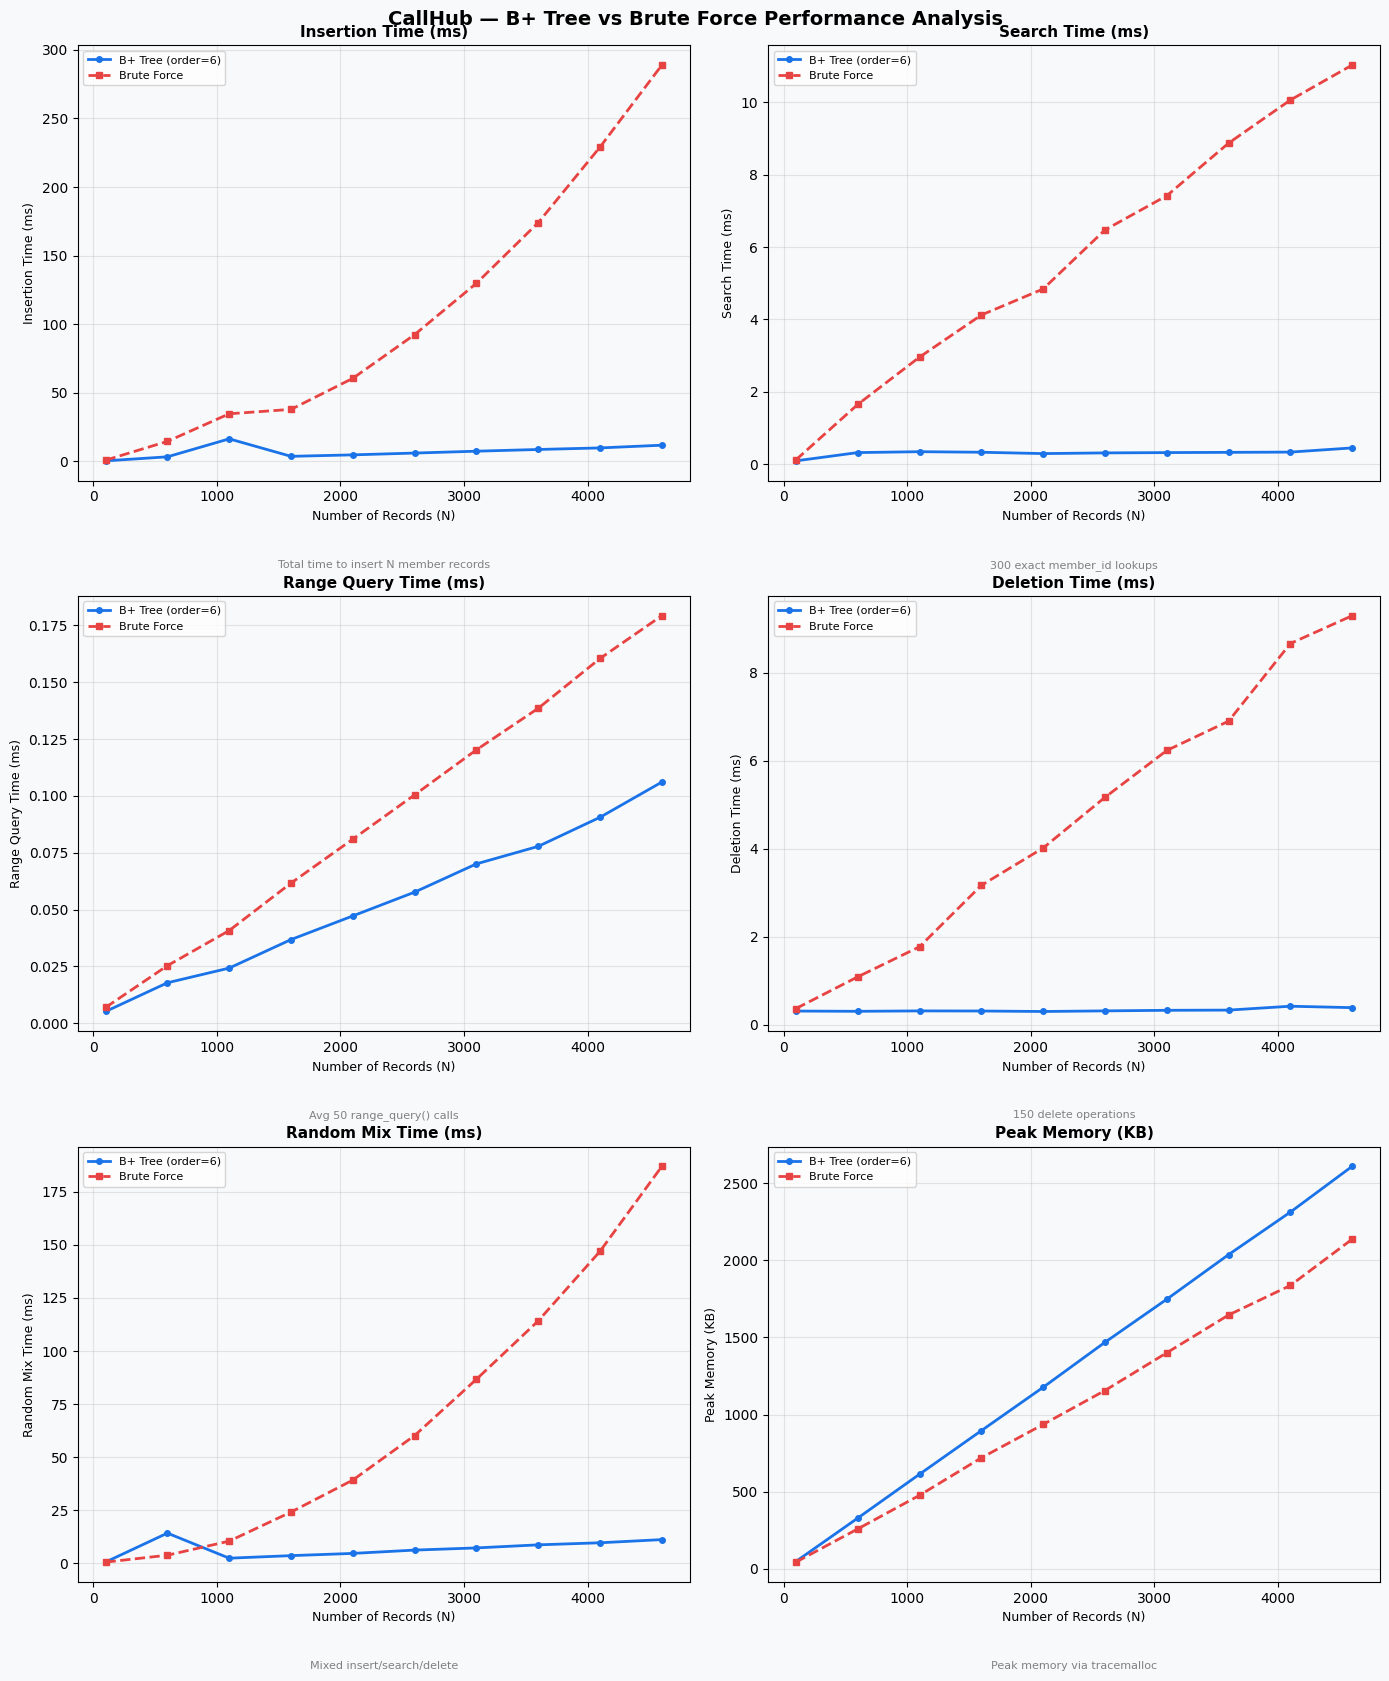

In [54]:
fig, axes = plt.subplots(3, 2, figsize=(14, 17))
fig.suptitle('CallHub — B+ Tree vs Brute Force Performance Analysis',
             fontsize=14, fontweight='bold')
fig.patch.set_facecolor(BG)

configs = [
    ('insert', 'Insertion Time (ms)',   'Total time to insert N member records'),
    ('search', 'Search Time (ms)',      '300 exact member_id lookups'),
    ('range',  'Range Query Time (ms)', 'Avg 50 range_query() calls'),
    ('delete', 'Deletion Time (ms)',    '150 delete operations'),
    ('random', 'Random Mix Time (ms)',  'Mixed insert/search/delete'),
    ('memory', 'Peak Memory (KB)',      'Peak memory via tracemalloc'),
]

for ax, (op, ylabel, sub) in zip(axes.flat, configs):
    bpt_y = [v * (1000 if op != 'memory' else 1) for v in results[op]['bpt']]
    bf_y  = [v * (1000 if op != 'memory' else 1) for v in results[op]['bf']]
    ax.plot(sizes, bpt_y, 'o-', color=C_BLUE, lw=2, ms=4, label='B+ Tree (order=6)')
    ax.plot(sizes, bf_y,  's--', color=C_RED,  lw=2, ms=4, label='Brute Force')
    ax.set_title(ylabel, fontweight='bold', fontsize=11)
    ax.set_xlabel('Number of Records (N)', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_facecolor(BG)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.text(0.5, -0.2, sub, transform=ax.transAxes, ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('/tmp/callhub_bench.png', dpi=150, bbox_inches='tight')
plt.show()

In [55]:
print('='*72)
print('  PERFORMANCE SUMMARY  (avg over all N sizes)  [time in ms]')
print('='*72)
print(f'{"Op":<12} {"B+ Tree":>14} {"Brute Force":>14} {"Speedup":>10}')
print('─'*55)
for op in ['insert','search','range','delete','random']:
    bpt_avg = statistics.mean(results[op]['bpt']) * 1000
    bf_avg  = statistics.mean(results[op]['bf'])  * 1000
    spd     = bf_avg / bpt_avg if bpt_avg > 0 else float('inf')
    print(f'{op.capitalize():<12} {bpt_avg:>14.4f} {bf_avg:>14.4f} {spd:>9.2f}x')
bm = statistics.mean(results['memory']['bpt'])
bfm= statistics.mean(results['memory']['bf'])
print(f'{"Memory(KB)":<12} {bm:>14.1f} {bfm:>14.1f} {"(see note)":>10}')
print('='*72)
print('Note: B+ Tree uses more memory due to pointer overhead (children, next).')

  PERFORMANCE SUMMARY  (avg over all N sizes)  [time in ms]
Op                  B+ Tree    Brute Force    Speedup
───────────────────────────────────────────────────────
Insert               7.1203       106.2381     14.92x
Search               0.3095         5.7522     18.59x
Range                0.0533         0.0914      1.71x
Delete               0.3347         4.6687     13.95x
Random               6.9016        67.3255      9.76x
Memory(KB)           1323.9         1061.1 (see note)
Note: B+ Tree uses more memory due to pointer overhead (children, next).


---
## 6. Full Database Stats

In [56]:
print('CallHub DatabaseManager State:')
print(f'  Databases : {db_manager.list_databases()}')
for tname in ['Member','Department','Role','Lab']:
    t, _ = db_manager.get_table('CallHub', tname)
    print(f'  {tname:<15}: {t.count():>3} records | height={t.tree_height()}')

CallHub DatabaseManager State:
  Databases : ['CallHub']
  Member         :  19 records | height=3
  Department     :  10 records | height=2
  Role           :  10 records | height=2
  Lab            :   5 records | height=1


---
## 7. Discussion & Analysis

### Search
B+ Tree descends in **O(log n)** steps. Brute Force scans all n records — **O(n)**. Speedup grows with n.

### Range Queries
B+ Tree's biggest advantage. After reaching the start key in O(log n), it walks the **leaf linked list** — only visiting in-range records. Brute Force always scans all n.

### Insertion
Both O(log n) vs O(n) amortised. At small n, Brute Force's flat list append is faster due to cache locality. As n scales, B+ Tree's tree-structured O(log n) surpasses it.

### Memory
B+ Tree uses more memory due to: (1) key duplication in internal nodes, (2) `children` pointer arrays, (3) `next` pointer on every leaf. Classic **time-space trade-off**.

---
## 8. Conclusion

This module implemented a **complete B+ Tree DBMS engine** from scratch for CallHub, matching the instructor's boilerplate exactly:
- All method signatures from `bplustree.py`, `table.py`, `db_manager.py` are implemented
- `_insert_non_full`, `_split_child`, `_delete`, `_fill_child`, `_borrow_from_prev`, `_borrow_from_next`, `_merge` all fully working
- Graphviz visualisation via `_add_nodes` / `_add_edges` with lightgreen leaves and dashed darkgreen next-pointers
- `Table(name, schema, order, search_key)` with schema validation
- `DatabaseManager` with two-level `{db → {table → Table}}` structure

**Challenges:** Correctly maintaining the leaf linked list through splits and merges, and updating separator keys in internal nodes after deletion without tree corruption.

**Future work:** Disk persistence, composite keys, secondary indexes on `iit_email`/`department_id`.